<hr style="border:2px solid #2196F3;">

## 🧑‍💻 Lecture 05 - Machine Learning and Model Evaluation

<hr style="border:2px solid #2196F3;">

## <b>🎯Linear Regression</b>

## 🔎 Data set: marketing.csv

<h3 style="color:blue">Problem description</h3>

<p>This case study analyzes the impact of marketing budget allocation on the sales of the product. The data set contains the marketing budget (in $1000 dollars) allocated to three different medias, namely television (TV), social networking site (SNS), and newspaper (poster), as well as the sales of product (in thousands of units). </p>

In [1]:
# import packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# read in the data from the csv file
mkt = pd.read_csv('marketing.csv')
print(mkt.head())

      TV     SNS  poster  sales
0   44.5   90.45    45.1   10.4
1   17.2  125.06    69.3    9.3
2  180.8  159.18    58.4   12.9
3    8.7   63.16    75.0    7.2
4   57.5  129.50    23.5   11.8


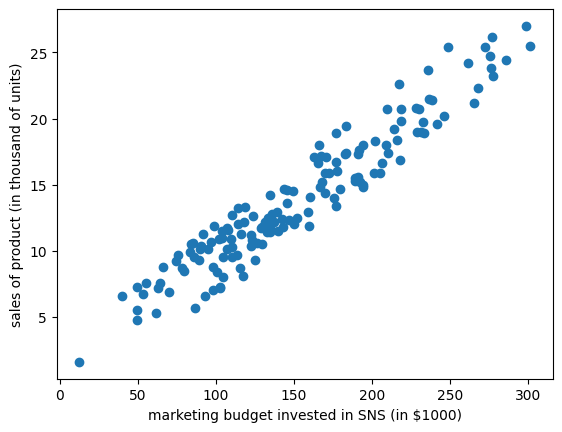

In [3]:
# assign the marketing budget spent in SNS as predictor variable x
x = mkt["SNS"]
# assign the sales value as response y
y = mkt["sales"]

# draw a scatter plot of x versus y
plt.scatter(x, y)
plt.xlabel('marketing budget invested in SNS (in $1000)')
plt.ylabel('sales of product (in thousand of units)')
plt.show()

In [4]:
# Fit a simple linear regression model
import statsmodels.api as sm

# Add a constant term beta_0 to the predictor variable
x1 = sm.add_constant(x)

model = sm.OLS(y, x1)

results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.913
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     1562.
Date:                Tue, 04 Aug 2026   Prob (F-statistic):           1.55e-80
Time:                        08:46:55   Log-Likelihood:                -276.34
No. Observations:                 150   AIC:                             556.7
Df Residuals:                     148   BIC:                             562.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.8169      0.332      5.468      0.0

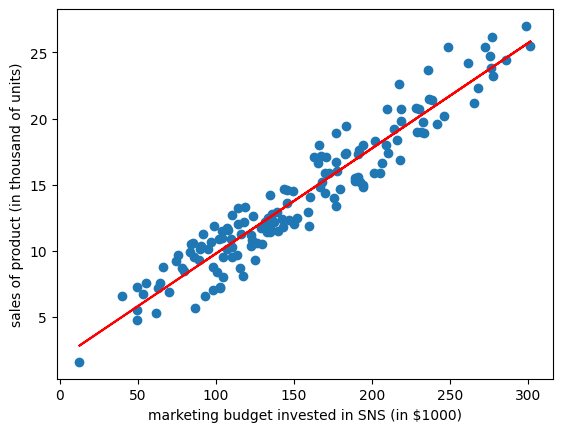

In [5]:
plt.scatter(x, y)
plt.xlabel('marketing budget invested in SNS (in $1000)')
plt.ylabel('sales of product (in thousand of units)')
plt.plot(x, results.predict(x1), 'r') #red
plt.show()

## <b>🎯Logistic Regression</b>

In [6]:
import statsmodels.api as sm
import pandas as pd

# loading the training dataset
df = pd.read_csv('Default.csv')

df.head()
# remark: take note the encoding in the data set
# student: 1; non-student: 0
# default: 1; non-default: 0

,default,student,loan,income
0,0,0,730,44362
1,0,1,817,12106
2,0,0,1074,31767
3,0,0,529,35704
4,0,0,786,38463


In [7]:
import statsmodels.api as sm
import pandas as pd

# defining the dependent and independent variables
x = df[['loan']]
y = df[['default']]

# Add a constant term beta_0 to the predictor variable
x1 = sm.add_constant(x)

model = sm.Logit(y, x1)

# building the model and fitting the data
log_reg = model.fit()

# printing the summary table
print(log_reg.summary())

Optimization terminated successfully.
         Current function value: 0.081399
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4998
Method:                           MLE   Df Model:                            1
Date:                Tue, 04 Aug 2026   Pseudo R-squ.:                  0.4635
Time:                        08:46:55   Log-Likelihood:                -407.00
converged:                       True   LL-Null:                       -758.57
Covariance Type:            nonrobust   LLR p-value:                6.177e-155
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.6591      0.502    -21.246      0.000     -11.642      -9.676
loan           0.0056      0

### ------ The fitted logistic regression model can be written as ------

$$
log(\frac{p(X)}{1-p(X)}) = -10.6591 + 0.0056X_{loan} + \epsilon
$$

                            OLS Regression Results                            
Dep. Variable:                default   R-squared:                       0.130
Model:                            OLS   Adj. R-squared:                  0.129
Method:                 Least Squares   F-statistic:                     743.7
Date:                Tue, 04 Aug 2026   Prob (F-statistic):          8.71e-153
Time:                        08:46:55   Log-Likelihood:                 1722.2
No. Observations:                5000   AIC:                            -3440.
Df Residuals:                    4998   BIC:                            -3427.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0784      0.005    -16.284      0.0

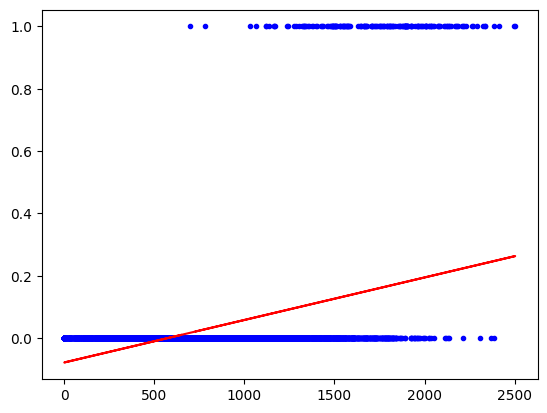

In [8]:
import matplotlib.pyplot as plt

# simple linear regression
x = df['loan']
y = df['default']

x1 = sm.add_constant(x)

model = sm.OLS(y, x1)
results = model.fit()
print(results.summary())

# plot the fitting results
plt.plot(x, y, 'b.') #blue
plt.plot(x, results.predict(x1), 'r') #red
plt.show()

###  ------ The fitted linear regression model can be written as ------
$$
y = -0.0784 + 0.0001X_{loan} + \epsilon
$$

Multiple Logistic Regression

In [9]:
# defining the dependent and independent variables
Xtrain = df[['student', 'loan']]
ytrain = df[['default']]

# Add a constant term beta_0 to the predictor variable
Xtrain_1 = sm.add_constant(Xtrain)

model = sm.Logit(ytrain, Xtrain_1)

# building the model and fitting the data
log_reg = model.fit()

# printing the summary table
print(log_reg.summary())

Optimization terminated successfully.
         Current function value: 0.079684
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4997
Method:                           MLE   Df Model:                            2
Date:                Tue, 04 Aug 2026   Pseudo R-squ.:                  0.4748
Time:                        08:46:56   Log-Likelihood:                -398.42
converged:                       True   LL-Null:                       -758.57
Covariance Type:            nonrobust   LLR p-value:                3.870e-157
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.8525      0.519    -20.921      0.000     -11.869      -9.836
student       -0.8402      0

### ------ The fitted logistic regression model can be written as ------

$$
log(\frac{p(X)}{1-p(X)}) = -10.8525 - 0.8402X_{student} + 0.0059X_{loan} + \epsilon
$$

In [10]:
# Finger exercise 2 part 2
import math

math.exp(-10.8525-0.8402*1+0.0059*2000)/(1+math.exp(-10.8525-0.8402*1+0.0059*2000))

0.526799292596919

## <b>🎯Confusion Matrix</b>

In [11]:
import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm

<h3 style="color:#E64C17">Data set: Default.csv</h3>
<p>The data set contains the profile information of 5,000 clients, as well as their default status (yes or no) in repayment of bank loans in the historical record. The case study tries to predict the chance of default for a new client who is applying for the bank loan. </p>

In [12]:
# The loan default data set
df = pd.read_csv('Default.csv')
df.head()

,default,student,loan,income
0,0,0,730,44362
1,0,1,817,12106
2,0,0,1074,31767
3,0,0,529,35704
4,0,0,786,38463


In [13]:
# defining the dependent and independent variables
X = df[['student', 'loan', 'income']]
y = df['default']
X.shape, y.shape

((5000, 3), (5000,))

<h3 style="color:#E64C17">Confusion Matrix</h3>

In [14]:
# Add a constant term beta_0 to the predictor variable
X_temp = sm.add_constant(X)

model = sm.Logit(y, X_temp)

# building the model and fitting the data
log_reg = model.fit()

# printing the summary table
# print(log_reg.summary())

Optimization terminated successfully.
         Current function value: 0.079505
         Iterations 10


In [15]:
# predicted prob of default based on the logistic reg model
y_pred = log_reg.predict()
print(y_pred)

# here we can set a threshold value alpha
# if prob of default < alpha, it is predicted as 'non-default'
# if prob of default >= alpha, it is predicted as 'default'
alpha = 0.5

for i in range(len(y_pred)):
    if y_pred[i] < alpha:
        y_pred[i] = 0
    else:
        y_pred[i] = 1

print(y_pred)

[1.52367621e-03 9.47777556e-04 9.43982696e-03 ... 7.45878043e-01
 4.68859287e-03 7.33891211e-04]
[0. 0. 0. ... 1. 0. 0.]


In [16]:
from sklearn.metrics import confusion_matrix
y_true = y

print(confusion_matrix(y_true, y_pred))

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
print("tn, fp, fn, tp:", tn, fp, fn, tp)

[[4803   22]
 [ 113   62]]
tn, fp, fn, tp: 4803 22 113 62
